Original shape: (13320, 9)

Missing values:
area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

After dropping missing values: (13303, 8)

BHK distribution:
bhk
1      656
2     5528
3     4856
4     1417
5      356
6      221
7      100
8       89
9       54
10      14
11       4
12       1
13       1
14       1
16       1
18       1
19       1
27       1
43       1
Name: count, dtype: int64

Total sqft stats:
count    13257.000000
mean      1558.809175
std       1238.478935
min          1.000000
25%       1100.000000
50%       1275.000000
75%       1680.000000
max      52272.000000
Name: total_sqft, dtype: float64

Price per sqft stats:
count    1.325700e+04
mean     7.912825e+03
std      1.064976e+05
min      2.678298e+02
25%      4.271186e+03
50%      5.438596e+03
75%      7.313318e+03
max      1.200000e+07
Name: price_per_sqft, dtyp

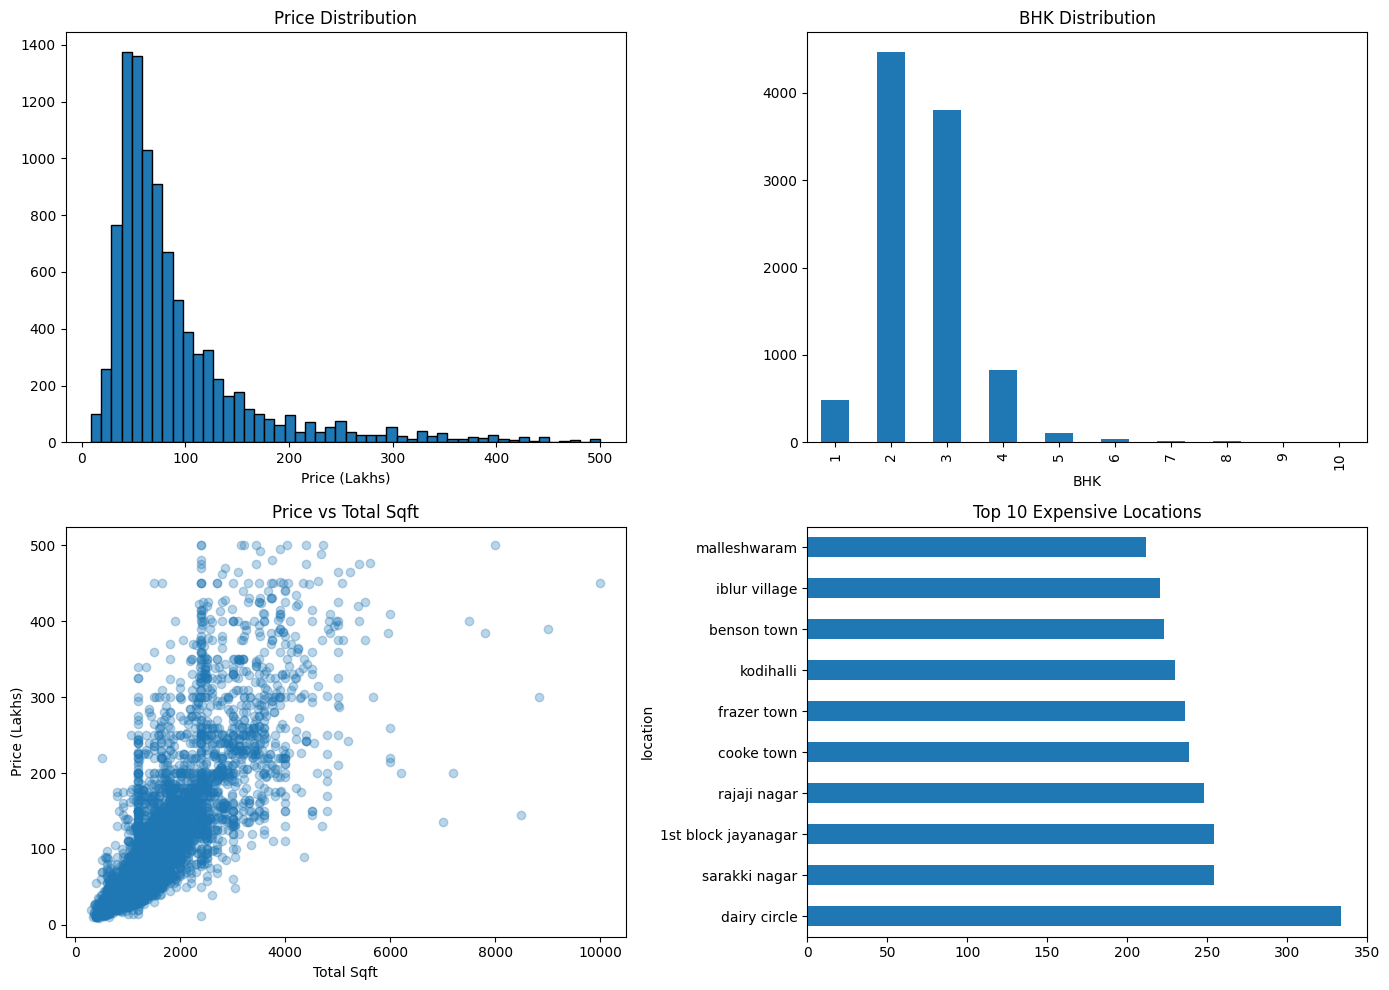


CLEANING COMPLETE!
Original records: 13,320
Final records: 9773
Columns: ['area_type', 'availability', 'location', 'bhk', 'total_sqft', 'bath', 'balcony', 'price', 'price_per_sqft', 'sqft_per_bhk']

Cleaned data saved as: bangalore_cleaned.csv

Sample of cleaned data:
              area_type   availability                  location  bhk  \
0  Super built-up  Area         19-Dec  electronic city phase ii    2   
1            Plot  Area  Ready To Move          chikka tirupathi    4   
2        Built-up  Area  Ready To Move               uttarahalli    3   
3  Super built-up  Area  Ready To Move        lingadheeranahalli    3   
4  Super built-up  Area  Ready To Move                  kothanur    2   

   total_sqft  bath  balcony   price  price_per_sqft  sqft_per_bhk  
0      1056.0   2.0      1.0   39.07     3699.810606         528.0  
1      2600.0   5.0      3.0  120.00     4615.384615         650.0  
2      1440.0   2.0      3.0   62.00     4305.555556         480.0  
3      1521.0  

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Bengaluru_House_Data.csv')

print("Original shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

df = df.dropna(subset=['location', 'size', 'price'])

df['bath'] = df.groupby('size')['bath'].transform(lambda x: x.fillna(x.median()))

df['balcony'] = df['balcony'].fillna(0)

df = df.drop('society', axis=1)

print("\nAfter dropping missing values:", df.shape)

def extract_bhk(size_str):
    try:
        return int(size_str.split()[0])
    except:
        return np.nan

df['bhk'] = df['size'].apply(extract_bhk)
df = df.dropna(subset=['bhk'])
df['bhk'] = df['bhk'].astype(int)

print("\nBHK distribution:")
print(df['bhk'].value_counts().sort_index())

def convert_sqft(x):
    try:
        if '-' in str(x):
            values = str(x).split('-')
            return (float(values[0]) + float(values[1])) / 2
        else:
            return float(x)
    except:
        return np.nan

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)
df = df.dropna(subset=['total_sqft'])

print("\nTotal sqft stats:")
print(df['total_sqft'].describe())

df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft']

print("\nPrice per sqft stats:")
print(df['price_per_sqft'].describe())

df['sqft_per_bhk'] = df['total_sqft'] / df['bhk']
df = df[df['sqft_per_bhk'] >= 300]

df = df[df['price'] <= 500]

df = df[df['total_sqft'] <= 10000]

print("\nAfter outlier removal:", df.shape)

df['location'] = df['location'].str.strip().str.lower()

location_counts = df['location'].value_counts()
locations_to_keep = location_counts[location_counts >= 10].index
df = df[df['location'].isin(locations_to_keep)]

print(f"\nNumber of locations: {df['location'].nunique()}")
print(f"Top 10 locations:")
print(df['location'].value_counts().head(10))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['price'], bins=50, edgecolor='black')
axes[0, 0].set_title('Price Distribution')
axes[0, 0].set_xlabel('Price (Lakhs)')

df['bhk'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('BHK Distribution')
axes[0, 1].set_xlabel('BHK')

axes[1, 0].scatter(df['total_sqft'], df['price'], alpha=0.3)
axes[1, 0].set_title('Price vs Total Sqft')
axes[1, 0].set_xlabel('Total Sqft')
axes[1, 0].set_ylabel('Price (Lakhs)')

top_locations = df.groupby('location')['price'].mean().sort_values(ascending=False).head(10)
top_locations.plot(kind='barh', ax=axes[1, 1])
axes[1, 1].set_title('Top 10 Expensive Locations')

plt.tight_layout()
plt.show()

final_df = df[['area_type', 'availability', 'location', 'bhk',
               'total_sqft', 'bath', 'balcony', 'price',
               'price_per_sqft', 'sqft_per_bhk']]

final_df.to_csv('bangalore_cleaned.csv', index=False)

print("\n" + "="*60)
print("CLEANING COMPLETE!")
print("="*60)
print(f"Original records: 13,320")
print(f"Final records: {len(final_df)}")
print(f"Columns: {list(final_df.columns)}")
print(f"\nCleaned data saved as: bangalore_cleaned.csv")
print("\nSample of cleaned data:")
print(final_df.head())